# Notebook 03: Exploratory Data Analysis

This notebook examines the final 2011–2025 Florida county-year feature panel
before vulnerability-score construction. The analysis focuses on housing
patterns, socioeconomic conditions, climate and disaster signals, NFIP losses,
affordability pressure, and the relationships between market indicators and
broader vulnerability conditions.


## 1. Setup and Data Validation

Notebook 02's final processed dataset is the only analytical input. Florida
county boundaries are loaded separately for the spatial figures.


In [ ]:
from pathlib import Path
import sys


def locate_project_root(start_path=None):
    start = Path(start_path or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "notebooks").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root containing notebooks/ and data/."
    )


PROJECT_ROOT = locate_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import (
    PROJECT_CMAPS,
    PROJECT_COLORS,
    STUDY_END_YEAR,
    STUDY_START_YEAR,
)
from src.visualization import (
    format_currency_axis,
    save_figure,
    save_table,
)


pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.3f}".format)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titleweight": "semibold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

COUNTY_YEAR_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "florida_county_year_features_2011_2025.csv"
)
SHAPEFILE_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "shapefiles"
    / "tl_2025_us_county"
    / "tl_2025_us_county.shp"
)
FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "eda"
TABLES_DIR = PROJECT_ROOT / "results" / "tables" / "eda"

for required_path in (COUNTY_YEAR_DATA_PATH, SHAPEFILE_PATH):
    if not required_path.exists():
        raise FileNotFoundError(f"Required input is missing: {required_path}")

county_year_df = pd.read_csv(
    COUNTY_YEAR_DATA_PATH,
    dtype={"STCOFIPS": str},
)
county_year_df["STCOFIPS"] = county_year_df["STCOFIPS"].str.zfill(5)

county_shapes = gpd.read_file(SHAPEFILE_PATH)
florida_shapes = county_shapes.loc[
    county_shapes["STATEFP"].astype(str).str.zfill(2).eq("12")
].copy()
florida_shapes["STCOFIPS"] = florida_shapes["GEOID"].astype(str).str.zfill(5)

duplicate_county_years = int(
    county_year_df.duplicated(["STCOFIPS", "Year"]).sum()
)
missing_value_count = int(county_year_df.isna().sum().sum())

validation_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "Counties",
            "Start year",
            "End year",
            "Duplicate county-years",
            "Missing values",
            "Florida boundary records",
        ],
        "Value": [
            len(county_year_df),
            county_year_df.shape[1],
            county_year_df["STCOFIPS"].nunique(),
            county_year_df["Year"].min(),
            county_year_df["Year"].max(),
            duplicate_county_years,
            missing_value_count,
            florida_shapes["STCOFIPS"].nunique(),
        ],
    }
)

expected_values = {
    "rows": 1000,
    "columns": 75,
    "counties": 67,
    "missing_values": 82,
}

if len(county_year_df) != expected_values["rows"]:
    raise ValueError("Expected 1,000 county-year observations.")
if county_year_df.shape[1] != expected_values["columns"]:
    raise ValueError("Expected 75 variables in the processed feature dataset.")
if county_year_df["STCOFIPS"].nunique() != expected_values["counties"]:
    raise ValueError("Expected 67 Florida counties.")
if not county_year_df["Year"].between(
    STUDY_START_YEAR, STUDY_END_YEAR
).all():
    raise ValueError("Observations fall outside the 2011–2025 study period.")
if duplicate_county_years:
    raise ValueError("Duplicate county-year observations found.")
if missing_value_count != expected_values["missing_values"]:
    raise ValueError("Unexpected missing-value count in the processed dataset.")

data_fips = set(county_year_df["STCOFIPS"])
shape_fips = set(florida_shapes["STCOFIPS"])
if data_fips != shape_fips:
    raise ValueError("County FIPS codes do not align with the shapefile.")

display(validation_summary)
display(
    county_year_df.isna().sum()
    .loc[lambda values: values.gt(0)]
    .rename("missing_values")
    .to_frame()
)


,Metric,Value
0,Rows,1000
1,Columns,75
2,Counties,67
3,Start year,2011
4,End year,2025
5,Duplicate county-years,0
6,Missing values,82
7,Florida boundary records,67


,missing_values
prev_year_housing_price,3
annual_price_growth_dollar,3
annual_price_growth_pct,3
price_growth_acceleration,70
high_growth_flag,3


## 2. Dataset Overview

The overview confirms coverage and summarizes the variables used in the EDA.


In [ ]:
variable_groups = {
    "Housing market": [
        "avg_annual_housing_price",
        "annual_price_growth_pct",
        "appreciation_from_baseline_pct",
        "annual_price_volatility",
        "price_growth_acceleration",
    ],
    "Climate exposure": ["CFLD_RISKS", "HRCN_RISKS"],
    "Disaster history": [
        "climate_disaster_count",
        "cumulative_climate_disaster_count",
        "recent_3yr_climate_disaster_count",
    ],
    "Socioeconomic and affordability": [
        "SOVI_SCORE",
        "RESL_SCORE",
        "median_household_income",
        "poverty_rate",
        "unemployment_rate",
        "renter_occupied_share",
        "price_to_income_ratio",
    ],
    "NFIP insurance loss": [
        "nfip_claim_count",
        "nfip_total_claim_payment",
        "nfip_cumulative_claim_payment",
        "nfip_recent_3yr_claim_payment",
    ],
    "Spatial neighbours": [
        "neighbor_avg_housing_price",
        "neighbor_avg_price_growth_pct",
        "neighbor_avg_price_volatility",
        "neighbor_high_growth_share",
        "neighbor_high_volatility_share",
    ],
}

variable_group_summary = pd.DataFrame(
    [
        {
            "Variable group": group,
            "Variables used": len(columns),
            "Columns": ", ".join(columns),
        }
        for group, columns in variable_groups.items()
    ]
)

summary_columns = [
    "avg_annual_housing_price",
    "annual_price_growth_pct",
    "appreciation_from_baseline_pct",
    "annual_price_volatility",
    "CFLD_RISKS",
    "HRCN_RISKS",
    "SOVI_SCORE",
    "RESL_SCORE",
    "cumulative_climate_disaster_count",
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "price_to_income_ratio",
    "nfip_cumulative_claim_payment",
    "neighbor_avg_price_growth_pct",
]

descriptive_summary = (
    county_year_df[summary_columns]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "Variable"})
)

county_summary = (
    county_year_df.groupby(["STCOFIPS", "RegionName"], as_index=False)
    .agg(
        avg_housing_price=("avg_annual_housing_price", "mean"),
        avg_annual_price_growth_pct=("annual_price_growth_pct", "mean"),
        total_appreciation_from_baseline_pct=(
            "appreciation_from_baseline_pct", "max"
        ),
        flood_risk=("CFLD_RISKS", "mean"),
        hurricane_risk=("HRCN_RISKS", "mean"),
        social_vulnerability=("SOVI_SCORE", "mean"),
        resilience=("RESL_SCORE", "mean"),
        cumulative_climate_disasters=(
            "cumulative_climate_disaster_count", "max"
        ),
        cumulative_nfip_claim_payment=(
            "nfip_cumulative_claim_payment", "max"
        ),
        avg_price_to_income_ratio=("price_to_income_ratio", "mean"),
    )
)

save_table(validation_summary, TABLES_DIR / "eda_coverage_summary.csv")
save_table(
    variable_group_summary,
    TABLES_DIR / "eda_variable_group_summary.csv",
)
save_table(
    descriptive_summary,
    TABLES_DIR / "eda_descriptive_statistics.csv",
)
save_table(county_summary, TABLES_DIR / "eda_county_level_summary.csv")
save_table(
    county_summary.nlargest(10, "avg_annual_price_growth_pct"),
    TABLES_DIR / "eda_top_growth_counties.csv",
)
save_table(
    county_summary.nlargest(10, "cumulative_climate_disasters"),
    TABLES_DIR / "eda_top_disaster_counties.csv",
)
save_table(
    county_summary.nlargest(10, "cumulative_nfip_claim_payment"),
    TABLES_DIR / "eda_top_nfip_counties.csv",
)
save_table(
    county_summary.nlargest(10, "social_vulnerability"),
    TABLES_DIR / "eda_top_social_vulnerability_counties.csv",
)

display(variable_group_summary)
display(descriptive_summary.round(2))
display(
    county_summary.nlargest(10, "avg_annual_price_growth_pct")[
        ["RegionName", "avg_annual_price_growth_pct"]
    ]
)


Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_coverage_summary.csv
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_variable_group_summary.csv
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_descriptive_statistics.csv
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_county_level_summary.csv
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_top_growth_counties.csv
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_top_disaster_counties.csv
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_top_nfip_counties.csv
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/cl

,Variable group,Variables used,Columns
0,Housing market,5,"avg_annual_housing_price, annual_price_growth_..."
1,Climate exposure,2,"CFLD_RISKS, HRCN_RISKS"
2,Disaster history,3,"climate_disaster_count, cumulative_climate_dis..."
3,Socioeconomic and affordability,7,"SOVI_SCORE, RESL_SCORE, median_household_incom..."
4,NFIP insurance loss,4,"nfip_claim_count, nfip_total_claim_payment, nf..."
5,Spatial neighbours,5,"neighbor_avg_housing_price, neighbor_avg_price..."


,Variable,count,mean,std,min,25%,50%,75%,max
0,avg_annual_housing_price,"1,000.000","215,760.540","118,805.160","69,581.750","128,794.820","188,718.650","272,562.170","993,480.730"
1,annual_price_growth_pct,997.000,6.290,7.950,-14.020,1.340,5.920,9.870,35.740
2,appreciation_from_baseline_pct,"1,000.000",57.050,61.680,-19.570,3.410,39.780,102.410,267.020
3,annual_price_volatility,"1,000.000","5,510.030","5,890.970",161.590,"2,161.470","3,834.140","6,172.370","57,938.920"
4,CFLD_RISKS,"1,000.000",47.540,37.730,0.000,0.000,61.200,78.550,99.600
5,HRCN_RISKS,"1,000.000",94.020,5.440,74.470,90.570,94.990,98.660,99.960
6,SOVI_SCORE,"1,000.000",57.800,23.420,11.390,39.890,56.680,75.860,97.900
7,RESL_SCORE,"1,000.000",32.340,22.900,0.670,10.910,29.450,47.770,96.280
8,cumulative_climate_disaster_count,"1,000.000",6.360,6.100,0.000,1.000,5.000,10.000,22.000
9,median_household_income,"1,000.000","52,710.890","14,197.130","29,806.000","41,522.500","49,682.000","60,779.500","118,559.100"


,RegionName,avg_annual_price_growth_pct
24,Hendry County,9.201
55,Saint Lucie County,9.131
42,Miami-Dade County,8.026
48,Osceola County,7.859
46,Okeechobee County,7.853
5,Broward County,7.780
20,Glades County,7.705
43,Monroe County,7.484
47,Orange County,7.358
25,Hernando County,7.350


## 3. Housing-Market Patterns

The first two figures compare the statewide price trajectory with the spatial
distribution of average annual county growth.


Saved figure: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/figures/eda/fig01_statewide_housing_price_trend_event_markers.png


,Year,statewide_avg_price,county_min_price,county_max_price
0,2011,"123,820.620","70,481.000","246,556.220"
1,2012,"122,216.850","69,581.750","247,305.240"
2,2013,"131,230.990","77,045.850","274,275.780"
3,2014,"142,503.330","81,389.260","301,363.830"
4,2015,"152,479.770","82,728.300","324,694.530"
5,2016,"169,728.030","89,627.310","513,522.060"
6,2017,"181,260.770","94,915.970","538,173.160"
7,2018,"194,544.370","97,937.600","558,908.440"
8,2019,"205,752.700","103,779.880","573,892.080"
9,2020,"220,323.940","114,008.840","607,133.610"


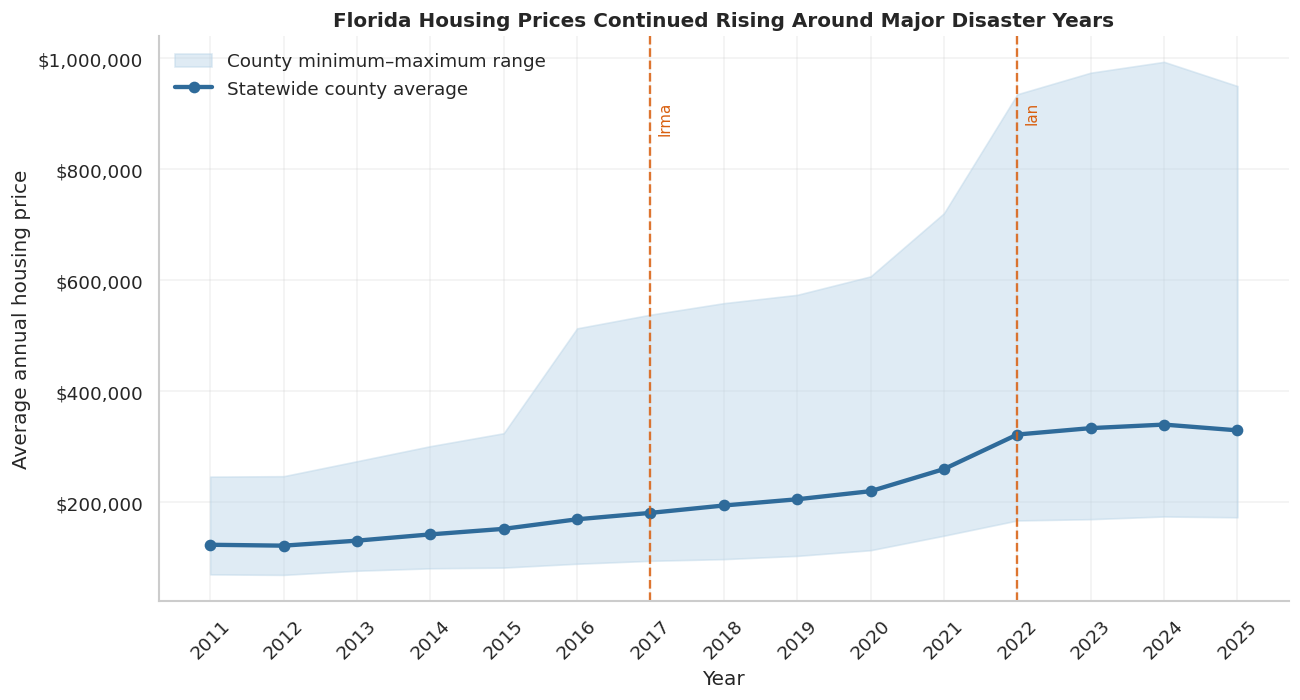

In [ ]:
statewide_price_trend = (
    county_year_df.groupby("Year", as_index=False)
    .agg(
        statewide_avg_price=("avg_annual_housing_price", "mean"),
        county_min_price=("avg_annual_housing_price", "min"),
        county_max_price=("avg_annual_housing_price", "max"),
    )
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(
    statewide_price_trend["Year"],
    statewide_price_trend["county_min_price"],
    statewide_price_trend["county_max_price"],
    color=PROJECT_COLORS["housing_light"],
    alpha=0.45,
    label="County minimum–maximum range",
)
ax.plot(
    statewide_price_trend["Year"],
    statewide_price_trend["statewide_avg_price"],
    color=PROJECT_COLORS["housing"],
    linewidth=2.6,
    marker="o",
    label="Statewide county average",
)

for year, label in {2017: "Irma", 2022: "Ian"}.items():
    ax.axvline(
        year,
        color=PROJECT_COLORS["climate"],
        linestyle="--",
        linewidth=1.4,
        alpha=0.85,
    )
    ax.text(
        year + 0.1,
        statewide_price_trend["county_max_price"].max() * 0.93,
        label,
        rotation=90,
        va="top",
        color=PROJECT_COLORS["climate"],
        fontsize=9,
    )

ax.set(
    title="Florida County-Level Housing Values, 2011–2025, with Major Hurricane Markers",
    xlabel="Year",
    ylabel="Average annual housing price",
)
ax.set_xticks(statewide_price_trend["Year"])
ax.tick_params(axis="x", rotation=45)
format_currency_axis(ax.yaxis)
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure(
    fig,
    FIGURES_DIR / "fig01_statewide_housing_price_trend_event_markers.png",
)
plt.show()

display(statewide_price_trend.round(2))


Saved figure: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/figures/eda/fig02_county_average_annual_price_growth_map.png


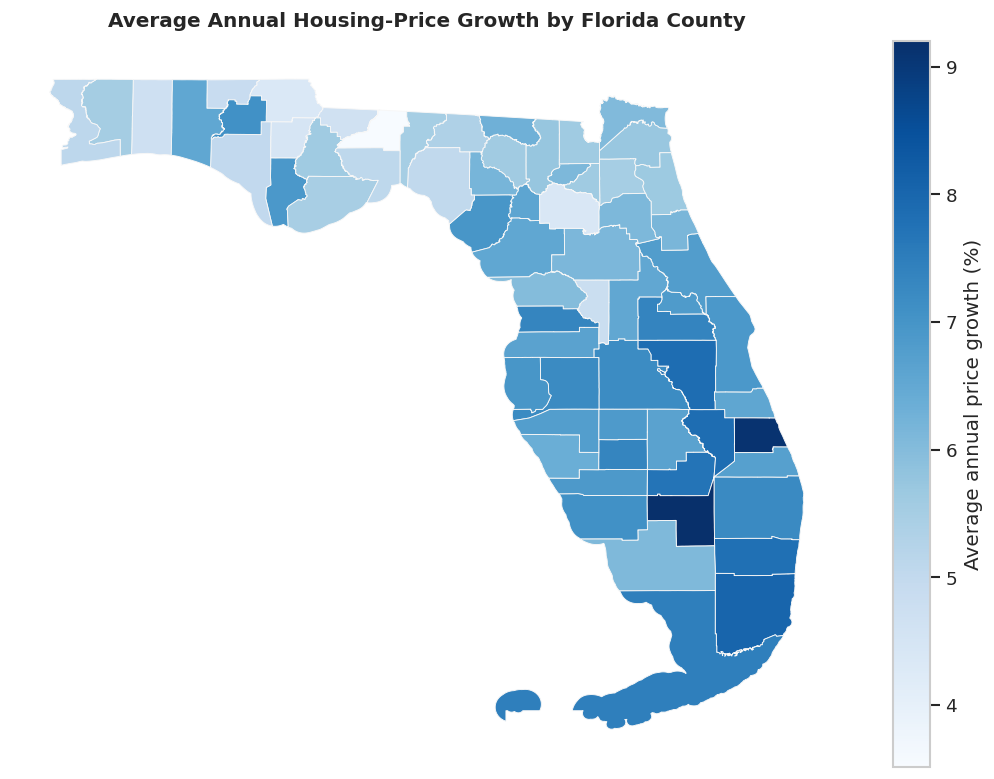

In [ ]:
county_price_growth = county_summary[
    ["STCOFIPS", "RegionName", "avg_annual_price_growth_pct"]
].copy()
price_growth_map = florida_shapes.merge(
    county_price_growth,
    on="STCOFIPS",
    how="left",
    validate="one_to_one",
)

if price_growth_map["avg_annual_price_growth_pct"].isna().any():
    raise ValueError("Housing-growth values are missing after the map merge.")

fig, ax = plt.subplots(figsize=(9, 9))
price_growth_map.plot(
    column="avg_annual_price_growth_pct",
    cmap=PROJECT_CMAPS["housing"],
    linewidth=0.55,
    edgecolor=PROJECT_COLORS["map_outline"],
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Average annual price growth (%)",
        "shrink": 0.7,
    },
)
ax.set_title("Average Annual Housing-Price Growth by Florida County", pad=12)
ax.axis("off")
fig.tight_layout()
save_figure(
    fig,
    FIGURES_DIR / "fig02_county_average_annual_price_growth_map.png",
)
plt.show()


The statewide county average increased from approximately **$123,821 in 2011**
to **$329,862 in 2025**. Growth was geographically uneven: the strongest
average annual increases occurred in Hendry, Saint Lucie, Miami-Dade, Osceola,
and Okeechobee counties.


## 4. Social Vulnerability and Resilience

The bivariate map distinguishes counties where higher social vulnerability
coincides with lower resilience. The accompanying map shows the underlying
social-vulnerability distribution.


Saved figure: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/figures/eda/fig03_social_vulnerability_resilience_bivariate_map.png


,Group,Counties
0,Lower vulnerability / higher resilience,23
1,Higher vulnerability / lower resilience,23
2,Higher vulnerability / higher resilience,11
3,Lower vulnerability / lower resilience,10


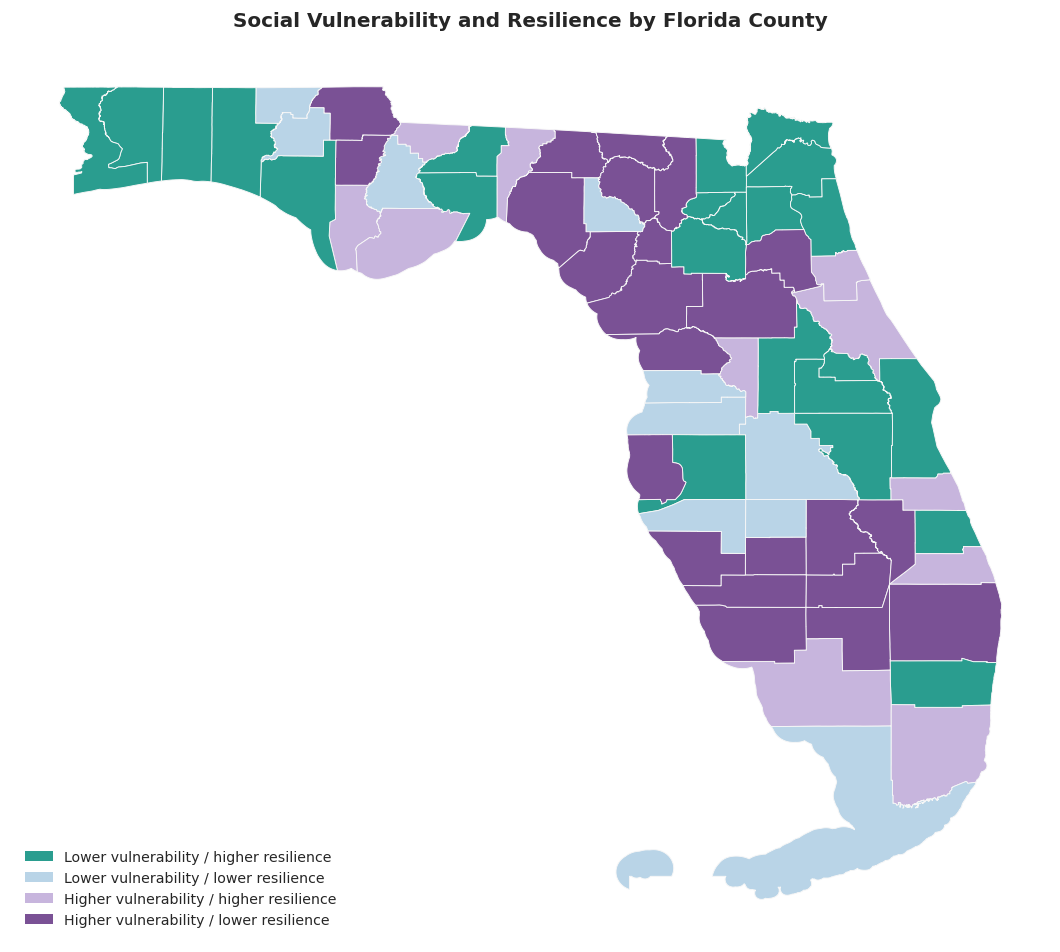

In [ ]:
county_social_resilience = county_summary[
    ["STCOFIPS", "RegionName", "social_vulnerability", "resilience"]
].copy()

sovi_median = county_social_resilience["social_vulnerability"].median()
resilience_median = county_social_resilience["resilience"].median()

county_social_resilience["social_resilience_group"] = np.select(
    [
        county_social_resilience["social_vulnerability"].lt(sovi_median)
        & county_social_resilience["resilience"].ge(resilience_median),
        county_social_resilience["social_vulnerability"].lt(sovi_median)
        & county_social_resilience["resilience"].lt(resilience_median),
        county_social_resilience["social_vulnerability"].ge(sovi_median)
        & county_social_resilience["resilience"].ge(resilience_median),
    ],
    [
        "Lower vulnerability / higher resilience",
        "Lower vulnerability / lower resilience",
        "Higher vulnerability / higher resilience",
    ],
    default="Higher vulnerability / lower resilience",
)

bivariate_colors = {
    "Lower vulnerability / higher resilience": PROJECT_COLORS["resilience"],
    "Lower vulnerability / lower resilience": "#B9D4E7",
    "Higher vulnerability / higher resilience": "#C7B5DD",
    "Higher vulnerability / lower resilience": PROJECT_COLORS["social"],
}

social_resilience_map = florida_shapes.merge(
    county_social_resilience,
    on="STCOFIPS",
    how="left",
    validate="one_to_one",
)
social_resilience_map["map_color"] = social_resilience_map[
    "social_resilience_group"
].map(bivariate_colors)

fig, ax = plt.subplots(figsize=(9, 9))
social_resilience_map.plot(
    color=social_resilience_map["map_color"],
    linewidth=0.55,
    edgecolor=PROJECT_COLORS["map_outline"],
    ax=ax,
)
legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=label)
    for label, color in bivariate_colors.items()
]
ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="lower left",
    fontsize=8.5,
)
ax.set_title("Social Vulnerability and Resilience by Florida County", pad=12)
ax.axis("off")
fig.tight_layout()
save_figure(
    fig,
    FIGURES_DIR / "fig03_social_vulnerability_resilience_bivariate_map.png",
)
plt.show()

display(
    county_social_resilience["social_resilience_group"]
    .value_counts()
    .rename_axis("Group")
    .reset_index(name="Counties")
)


Saved figure: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/figures/eda/fig04_socioeconomic_vulnerability_map.png


,RegionName,social_vulnerability,resilience
31,Jefferson County,97.901,32.188
18,Gadsden County,95.038,33.810
26,Highlands County,94.116,5.693
36,Levy County,93.448,9.160
12,De Soto County,90.840,1.399
24,Hendry County,90.299,0.668
59,Sumter County,90.045,46.978
20,Glades County,89.726,0.922
61,Taylor County,89.408,26.749
22,Hamilton County,89.027,8.397


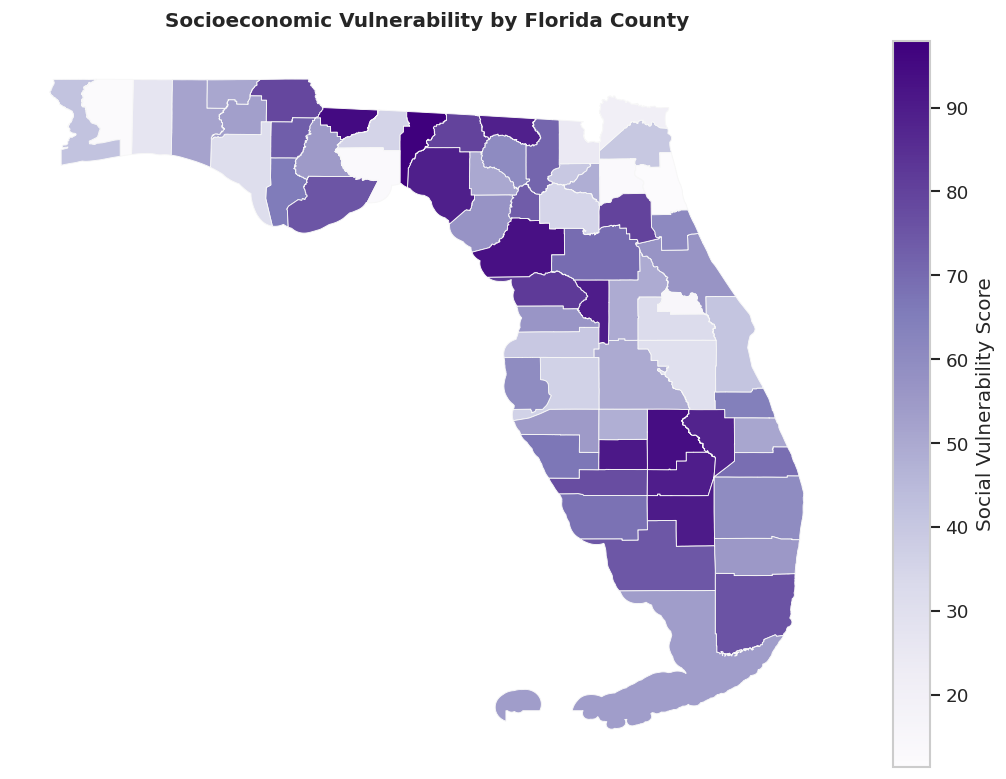

In [ ]:
social_vulnerability_map = florida_shapes.merge(
    county_social_resilience[
        ["STCOFIPS", "RegionName", "social_vulnerability"]
    ],
    on="STCOFIPS",
    how="left",
    validate="one_to_one",
)

fig, ax = plt.subplots(figsize=(9, 9))
social_vulnerability_map.plot(
    column="social_vulnerability",
    cmap=PROJECT_CMAPS["social"],
    linewidth=0.55,
    edgecolor=PROJECT_COLORS["map_outline"],
    legend=True,
    ax=ax,
    legend_kwds={"label": "Social Vulnerability Score", "shrink": 0.7},
)
ax.set_title("Socioeconomic Vulnerability by Florida County", pad=12)
ax.axis("off")
fig.tight_layout()
save_figure(
    fig,
    FIGURES_DIR / "fig04_socioeconomic_vulnerability_map.png",
)
plt.show()

display(
    county_social_resilience.nlargest(10, "social_vulnerability")[
        ["RegionName", "social_vulnerability", "resilience"]
    ]
)


The two indicators are not interchangeable. Several inland and rural counties
combine relatively high social vulnerability with lower resilience, supporting
their separate treatment in the vulnerability framework.


## 5. Climate Exposure, Disaster History, and NFIP Losses

Static NRI exposure, accumulated disaster declarations, and realized insured
flood losses represent distinct dimensions of climate-related stress.


Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_county_climate_exposure_disaster_summary.csv
Saved figure: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/figures/eda/fig05_climate_exposure_vs_cumulative_disaster_count.png


,RegionName,combined_climate_exposure,cumulative_climate_disasters
8,Citrus County,95.695,22
61,Taylor County,84.650,22
2,Bay County,87.932,21
10,Collier County,97.475,21
13,Dixie County,80.354,21
17,Franklin County,83.944,21
19,Gilchrist County,55.036,21
25,Hernando County,85.139,21
31,Jefferson County,63.067,21
36,Levy County,82.107,21


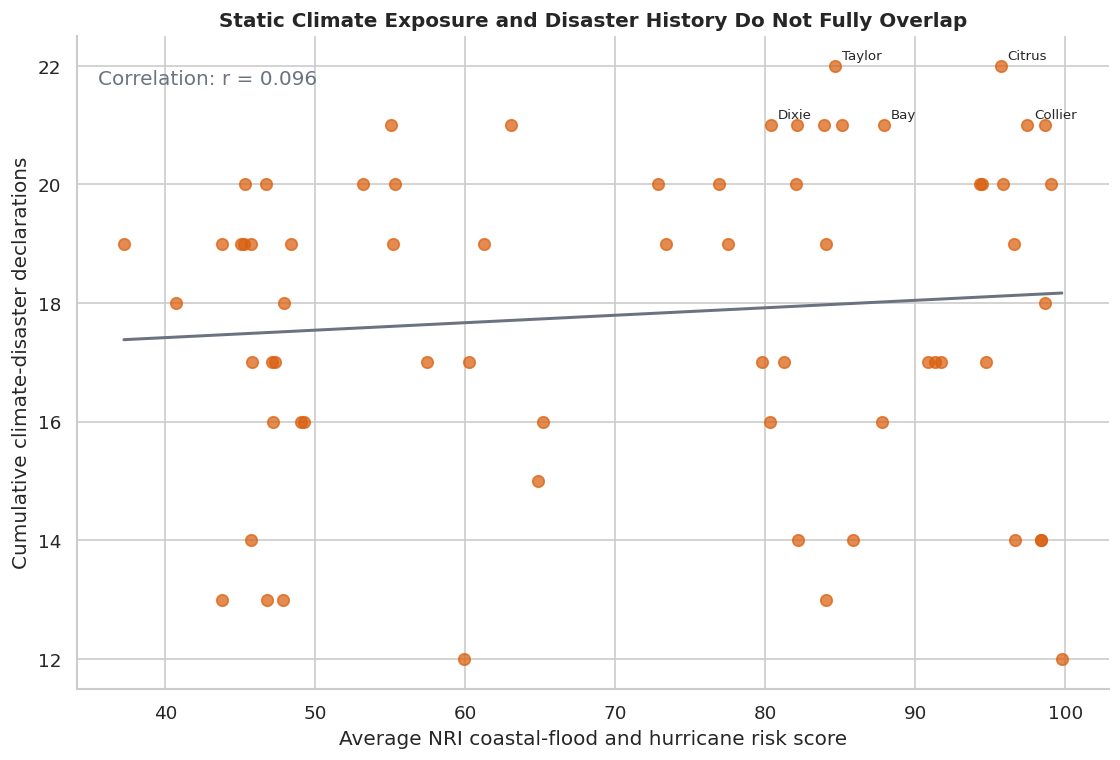

In [ ]:
climate_disaster_summary = county_summary.copy()
climate_disaster_summary["combined_climate_exposure"] = (
    climate_disaster_summary[["flood_risk", "hurricane_risk"]].mean(axis=1)
)

exposure_disaster_correlation = climate_disaster_summary[
    ["combined_climate_exposure", "cumulative_climate_disasters"]
].corr().iloc[0, 1]

save_table(
    climate_disaster_summary,
    TABLES_DIR / "eda_county_climate_exposure_disaster_summary.csv",
)

fig, ax = plt.subplots(figsize=(9.5, 6.5))
sns.regplot(
    data=climate_disaster_summary,
    x="combined_climate_exposure",
    y="cumulative_climate_disasters",
    scatter_kws={
        "color": PROJECT_COLORS["climate"],
        "alpha": 0.72,
        "s": 48,
    },
    line_kws={"color": PROJECT_COLORS["neutral"], "linewidth": 1.8},
    ci=None,
    ax=ax,
)

for _, row in climate_disaster_summary.nlargest(
    5, "cumulative_climate_disasters"
).iterrows():
    ax.annotate(
        row["RegionName"].replace(" County", ""),
        (row["combined_climate_exposure"], row["cumulative_climate_disasters"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set(
    title="Static Climate Exposure and Disaster History Do Not Fully Overlap",
    xlabel="Average NRI coastal-flood and hurricane risk score",
    ylabel="Cumulative climate-disaster declarations",
)
ax.text(
    0.02,
    0.95,
    f"Correlation: r = {exposure_disaster_correlation:.3f}",
    transform=ax.transAxes,
    va="top",
    color=PROJECT_COLORS["neutral"],
)
fig.tight_layout()
save_figure(
    fig,
    FIGURES_DIR / "fig05_climate_exposure_vs_cumulative_disaster_count.png",
)
plt.show()

display(
    climate_disaster_summary.nlargest(10, "cumulative_climate_disasters")[
        [
            "RegionName",
            "combined_climate_exposure",
            "cumulative_climate_disasters",
        ]
    ]
)


Saved figure: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/figures/eda/fig06_nfip_cumulative_claim_payments_map.png
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_county_nfip_cumulative_claim_payment_summary.csv


,RegionName,cumulative_nfip_claim_payment
34,Lee County,"3,878,871,800.620"
51,Pinellas County,"3,565,829,110.660"
27,Hillsborough County,"1,126,276,724.110"
10,Collier County,"1,114,534,735.900"
57,Sarasota County,"820,323,432.620"
39,Manatee County,"621,365,987.870"
50,Pasco County,"589,065,143.030"
63,Volusia County,"531,585,130.980"
7,Charlotte County,"461,155,716.860"
5,Broward County,"370,567,774.030"


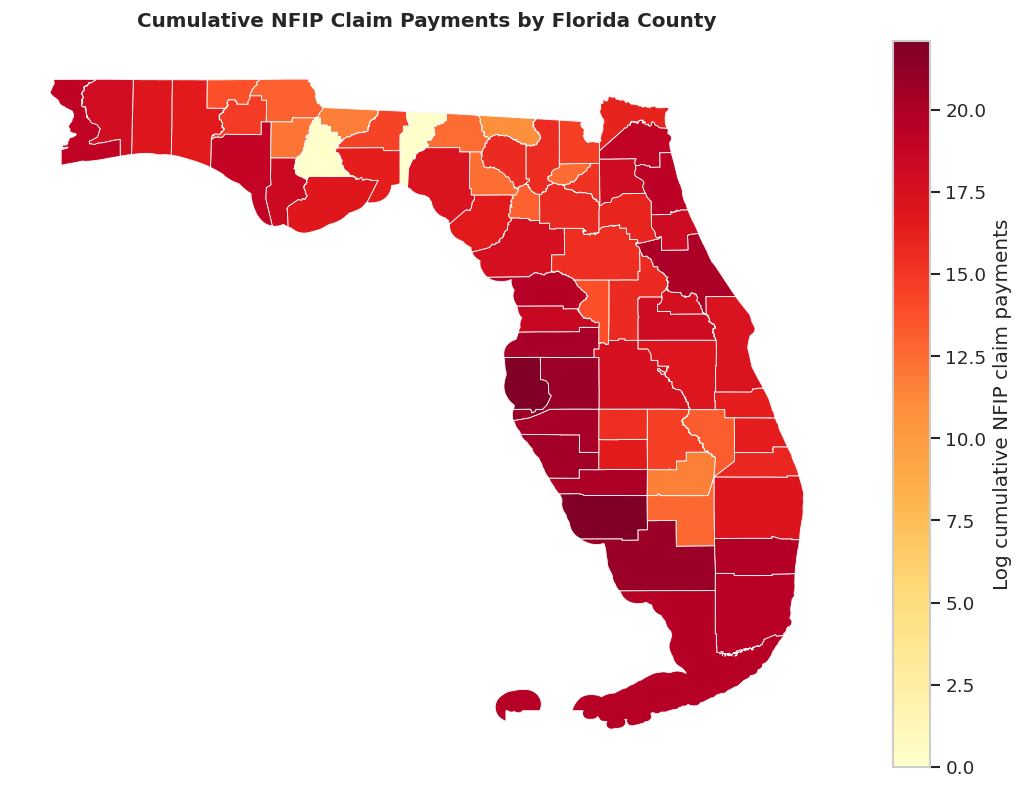

In [ ]:
county_nfip_losses = county_summary[
    ["STCOFIPS", "RegionName", "cumulative_nfip_claim_payment"]
].copy()
county_nfip_losses["log_nfip_cumulative_claim_payment"] = np.log1p(
    county_nfip_losses["cumulative_nfip_claim_payment"]
)

nfip_loss_map = florida_shapes.merge(
    county_nfip_losses,
    on="STCOFIPS",
    how="left",
    validate="one_to_one",
)

fig, ax = plt.subplots(figsize=(9, 9))
nfip_loss_map.plot(
    column="log_nfip_cumulative_claim_payment",
    cmap=PROJECT_CMAPS["nfip"],
    linewidth=0.55,
    edgecolor=PROJECT_COLORS["map_outline"],
    legend=True,
    ax=ax,
    legend_kwds={"label": "Log cumulative NFIP claim payments", "shrink": 0.7},
)
ax.set_title("Cumulative NFIP Claim Payments by Florida County", pad=12)
ax.axis("off")
fig.tight_layout()
save_figure(
    fig,
    FIGURES_DIR / "fig06_nfip_cumulative_claim_payments_map.png",
)
plt.show()

save_table(
    county_nfip_losses,
    TABLES_DIR / "eda_county_nfip_cumulative_claim_payment_summary.csv",
)
display(
    county_nfip_losses.nlargest(10, "cumulative_nfip_claim_payment")[
        ["RegionName", "cumulative_nfip_claim_payment"]
    ]
)


Static exposure and cumulative disaster history are only weakly correlated
(***r*** ≈ 0.096). NFIP losses are substantially more concentrated: Lee and
Pinellas counties each exceed $3.5 billion in cumulative claim payments.


## 6. Affordability and Market Stress

Counties are divided into terciles using their average annual housing-price
growth. Their price-to-income trajectories are then compared over time.


Saved figure: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/figures/eda/fig07_price_to_income_ratio_trend_by_growth_group.png
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_county_growth_group_summary.csv
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_affordability_trend_by_growth_group.csv
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_affordability_change_summary_by_growth_group.csv


,growth_group,2011,2025,absolute_change,percent_change
0,Lower-growth counties,2.911,3.930,1.019,34.988
1,Moderate-growth counties,2.881,4.551,1.670,57.963
2,Higher-growth counties,2.491,4.916,2.425,97.336


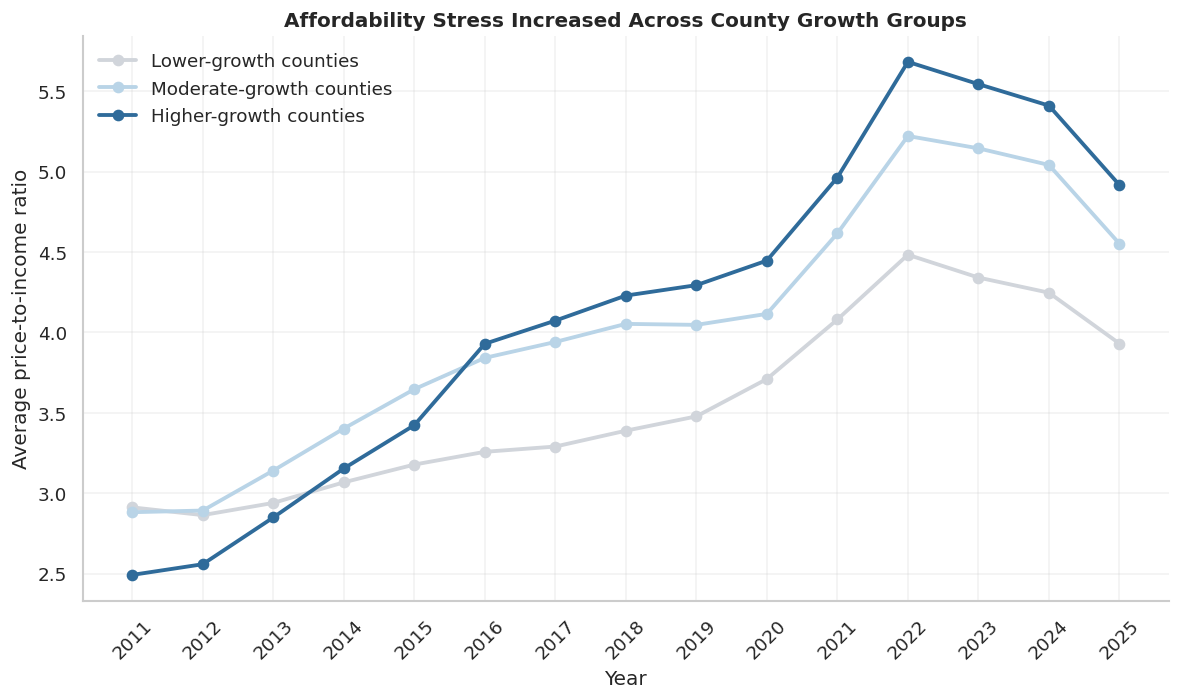

In [ ]:
county_growth_summary = county_summary[
    [
        "STCOFIPS",
        "RegionName",
        "avg_annual_price_growth_pct",
        "avg_price_to_income_ratio",
        "flood_risk",
        "hurricane_risk",
    ]
].copy()

growth_group_order = [
    "Lower-growth counties",
    "Moderate-growth counties",
    "Higher-growth counties",
]
county_growth_summary["growth_group"] = pd.qcut(
    county_growth_summary["avg_annual_price_growth_pct"],
    q=3,
    labels=growth_group_order,
)

affordability_panel = county_year_df.merge(
    county_growth_summary[["STCOFIPS", "RegionName", "growth_group"]],
    on=["STCOFIPS", "RegionName"],
    how="left",
    validate="many_to_one",
)

affordability_trend = (
    affordability_panel.groupby(
        ["Year", "growth_group"], as_index=False, observed=True
    )
    .agg(
        avg_price_to_income_ratio=("price_to_income_ratio", "mean"),
        median_price_to_income_ratio=("price_to_income_ratio", "median"),
        avg_housing_price=("avg_annual_housing_price", "mean"),
        avg_median_household_income=("median_household_income", "mean"),
        county_count=("STCOFIPS", "nunique"),
    )
)

start_end = (
    affordability_trend.loc[
        affordability_trend["Year"].isin(
            [STUDY_START_YEAR, STUDY_END_YEAR]
        )
    ]
    .pivot(
        index="growth_group",
        columns="Year",
        values="avg_price_to_income_ratio",
    )
    .reindex(growth_group_order)
    .reset_index()
)
start_end.columns.name = None
start_end["absolute_change"] = (
    start_end[STUDY_END_YEAR] - start_end[STUDY_START_YEAR]
)
start_end["percent_change"] = (
    start_end["absolute_change"] / start_end[STUDY_START_YEAR] * 100
)

growth_colors = {
    "Lower-growth counties": PROJECT_COLORS["light_neutral"],
    "Moderate-growth counties": PROJECT_COLORS["housing_light"],
    "Higher-growth counties": PROJECT_COLORS["housing"],
}

fig, ax = plt.subplots(figsize=(10, 6))
for group_name in growth_group_order:
    group_data = affordability_trend.loc[
        affordability_trend["growth_group"].eq(group_name)
    ].sort_values("Year")
    ax.plot(
        group_data["Year"],
        group_data["avg_price_to_income_ratio"],
        color=growth_colors[group_name],
        marker="o",
        linewidth=2.3,
        label=group_name,
    )

ax.set(
    title="Affordability Stress Increased Across County Growth Groups",
    xlabel="Year",
    ylabel="Average price-to-income ratio",
)
ax.set_xticks(range(STUDY_START_YEAR, STUDY_END_YEAR + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure(
    fig,
    FIGURES_DIR / "fig07_price_to_income_ratio_trend_by_growth_group.png",
)
plt.show()

save_table(
    county_growth_summary,
    TABLES_DIR / "eda_county_growth_group_summary.csv",
)
save_table(
    affordability_trend,
    TABLES_DIR / "eda_affordability_trend_by_growth_group.csv",
)
save_table(
    start_end,
    TABLES_DIR / "eda_affordability_change_summary_by_growth_group.csv",
)
display(start_end.round(3))


Affordability pressure increased in every group. The price-to-income ratio rose
most sharply in higher-growth counties—from 2.49 in 2011 to 4.92 in 2025, an
increase of approximately 97.3%.


## 7. Housing Signals and Broader Vulnerability Conditions

The focused heatmap tests whether housing indicators act as reliable proxies
for climate exposure, disaster history, NFIP losses, social vulnerability, and
resilience.


Saved figure: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/figures/eda/fig08_housing_signals_vs_vulnerability_stress_heatmap.png
Saved table: /workspace/scratch/dbc5196f4a90/audit_copy/climate-risk-housing-valuation/results/tables/eda/eda_focused_housing_vulnerability_correlation_matrix.csv


,Housing price,Annual price growth,Baseline appreciation,Price volatility,Growth acceleration,Price-to-income ratio
Coastal flood risk,0.364,0.027,0.095,0.251,-0.013,0.331
Hurricane risk,0.297,0.035,0.120,0.243,-0.004,0.315
Cumulative disasters,0.609,0.056,0.834,0.229,-0.373,0.488
NFIP claim payments,0.532,0.251,0.462,0.397,-0.161,0.488
Social vulnerability,-0.177,0.021,0.020,-0.103,-0.008,0.035
Resilience,0.297,-0.041,-0.046,0.141,0.005,0.182


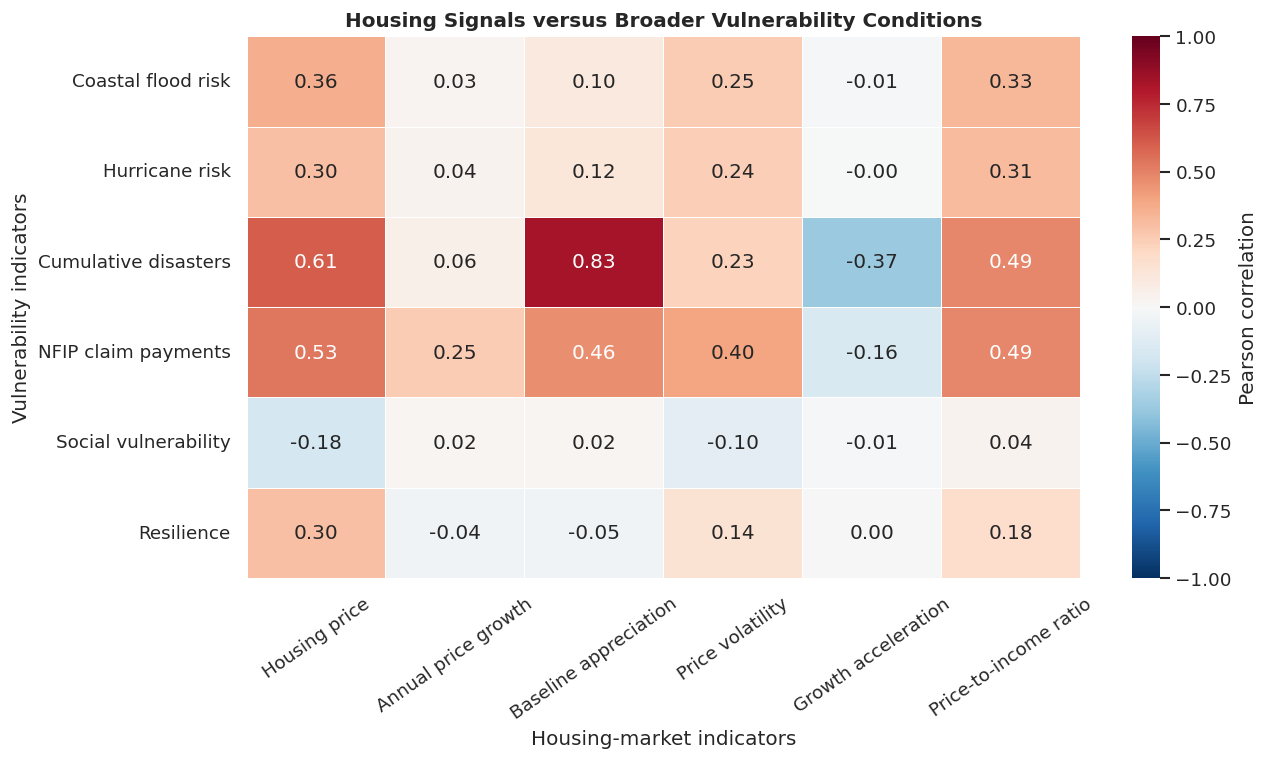

In [ ]:
correlation_df = county_year_df.copy()
correlation_df["log_annual_price_volatility"] = np.log1p(
    correlation_df["annual_price_volatility"]
)
correlation_df["log_nfip_cumulative_claim_payment"] = np.log1p(
    correlation_df["nfip_cumulative_claim_payment"]
)

housing_signal_vars = [
    "avg_annual_housing_price",
    "annual_price_growth_pct",
    "appreciation_from_baseline_pct",
    "log_annual_price_volatility",
    "price_growth_acceleration",
    "price_to_income_ratio",
]
vulnerability_stress_vars = [
    "CFLD_RISKS",
    "HRCN_RISKS",
    "cumulative_climate_disaster_count",
    "log_nfip_cumulative_claim_payment",
    "SOVI_SCORE",
    "RESL_SCORE",
]
variable_labels = {
    "avg_annual_housing_price": "Housing price",
    "annual_price_growth_pct": "Annual price growth",
    "appreciation_from_baseline_pct": "Baseline appreciation",
    "log_annual_price_volatility": "Price volatility",
    "price_growth_acceleration": "Growth acceleration",
    "price_to_income_ratio": "Price-to-income ratio",
    "CFLD_RISKS": "Coastal flood risk",
    "HRCN_RISKS": "Hurricane risk",
    "cumulative_climate_disaster_count": "Cumulative disasters",
    "log_nfip_cumulative_claim_payment": "NFIP claim payments",
    "SOVI_SCORE": "Social vulnerability",
    "RESL_SCORE": "Resilience",
}

focused_corr_matrix = (
    correlation_df[housing_signal_vars + vulnerability_stress_vars]
    .corr()
    .loc[vulnerability_stress_vars, housing_signal_vars]
    .rename(index=variable_labels, columns=variable_labels)
)

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(
    focused_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=PROJECT_CMAPS["correlation"],
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set(
    title="Housing Signals versus Broader Vulnerability Conditions",
    xlabel="Housing-market indicators",
    ylabel="Vulnerability indicators",
)
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
save_figure(
    fig,
    FIGURES_DIR / "fig08_housing_signals_vs_vulnerability_stress_heatmap.png",
)
plt.show()

save_table(
    focused_corr_matrix.reset_index().rename(
        columns={"index": "Vulnerability indicator"}
    ),
    TABLES_DIR / "eda_focused_housing_vulnerability_correlation_matrix.csv",
)
display(focused_corr_matrix.round(3))


Housing measures reflect some disaster and financial-loss patterns but provide
little information about social vulnerability. Annual price growth is weakly
correlated with most broader stress indicators, reinforcing the need for a
multidimensional vulnerability measure.


## 8. EDA Summary

- Florida housing prices increased strongly but unevenly across counties.
- Social vulnerability and resilience exhibit distinct spatial patterns.
- Static climate exposure, disaster history, and NFIP losses capture different
  forms of stress.
- Affordability pressure increased fastest in higher-growth counties.
- Housing indicators alone do not reveal the full vulnerability structure.

Notebook 04 therefore constructs the multidimensional climate-housing
vulnerability score from the complementary feature groups identified here.
